# Modélisation Machine Learning : Facteurs d'Allaitement (EDS Cameroun 2018)
    
Ce notebook a pour objectif de construire un modèle prédictif de Machine Learning très puissant pour l'Allaitement Maternel Exclusif (AME). 
Nous utilisons le jeu de données décodé.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import pickle
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et Préparation des données

In [2]:
df_raw = pd.read_excel('dataset_allaitement_edsc2018_decode.xlsx', sheet_name='data')

df = df_raw.copy()
for col in ['Age_Enfant_Mois', 'Duree_Allaitement_Mois', 'Age_Mere_Actuel', 'Nombre_Visites_Prenatales']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[df['Age_Enfant_Mois'] < 6].copy()

def determine_ame(row):
    if str(row['Allaitement_Actuel']).strip().lower() not in ['yes', 'oui', '1.0', '1']: return 0
    if str(row['Donne_Eau_Claire']).strip().lower() in ['yes', 'oui', '1.0', '1']: return 0
    if str(row['Donne_Nourriture_Solide']).strip().lower() in ['yes', 'oui', '1.0', '1']: return 0
    if str(row['Donne_Yaourt']).strip().lower() in ['yes', 'oui', '1.0', '1']: return 0
    try:
        if float(row['Fois_Mange_Solide_Hier']) > 0 and float(row['Fois_Mange_Solide_Hier']) < 90: return 0
    except: pass
    return 1

df['AME'] = df.apply(determine_ame, axis=1)

df['Age_Mere_Cat'] = pd.cut(df['Age_Mere_Actuel'], bins=[14, 24, 34, 49], labels=['15-24', '25-34', '35-49'])

def recode_cpon(val):
    if pd.isna(val) or val > 50: return 'Inconnu'
    if val < 4: return '< 4 visites'
    return '>= 4 visites'
df['Visites_Prenatales_Cat'] = df['Nombre_Visites_Prenatales'].apply(recode_cpon)

def recode_lieu(val):
    v = str(val).lower()
    if 'home' in v or 'domicile' in v: return 'Domicile'
    if 'hospital' in v or 'hopital' in v or 'health' in v or 'sante' in v or 'centre' in v: return 'Formation Sanitaire'
    return 'Autre'
df['Lieu_Accouchement_Cat'] = df['Lieu_Accouchement'].apply(recode_lieu)

cols_analyse = ['AME', 'Age_Mere_Cat', 'Sexe_Enfant', 'Milieu_Residence', 'Niveau_Education', 'Indice_Richesse', 'Lieu_Accouchement_Cat', 'Visites_Prenatales_Cat']
df_ml = df[cols_analyse].dropna().copy()
print(f"Jeu de données ML prêt : {df_ml.shape}")

Jeu de données ML prêt : (1053, 8)


In [3]:
X = pd.get_dummies(df_ml.drop('AME', axis=1), drop_first=True)
y = df_ml['AME']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (842, 8), Test: (211, 8)


## 2. Entraînement et Évaluation

In [4]:
modeles = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultats = []
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_prob = modele.predict_proba(X_test)[:, 1]
    resultats.append({
        'Modèle': nom, 'Accuracy': accuracy_score(y_test, y_pred),
        'Précision': precision_score(y_test, y_pred), 'Rappel': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred), 'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

df_resultats = pd.DataFrame(resultats).set_index('Modèle')
display(df_resultats.round(3))

best_model_name = df_resultats['ROC-AUC'].idxmax()
best_model = modeles[best_model_name]
print(f"Meilleur modèle : {best_model_name}")

,Accuracy,Précision,Rappel,F1-Score,ROC-AUC
Modèle,,,,,
Régression Logistique,0.564,0.500,0.620,0.553,0.608
Random Forest,0.536,0.470,0.511,0.490,0.547
Gradient Boosting,0.578,0.533,0.261,0.350,0.569


Meilleur modèle : Régression Logistique


## 3. Visualisations Avancées du Meilleur Modèle

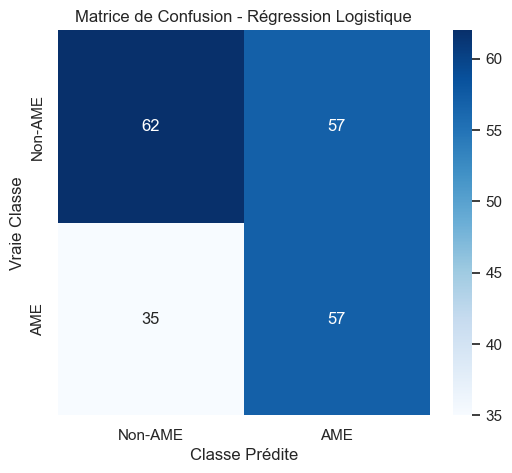

In [5]:
# 1. Matrice de confusion
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-AME', 'AME'], yticklabels=['Non-AME', 'AME'])
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

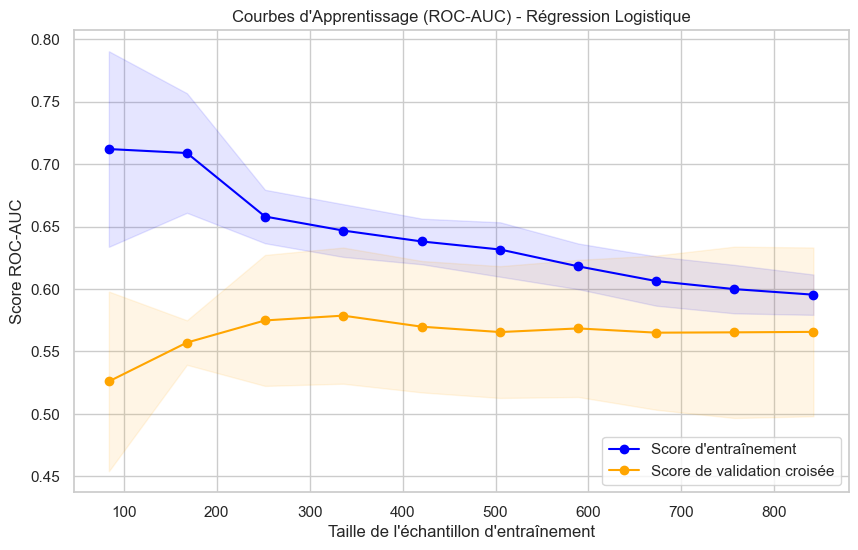

In [6]:
# 2. Courbes d'Apprentissage (Learning Curves)
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Score d\'entraînement')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Score de validation croisée')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

plt.title('Courbes d\'Apprentissage (ROC-AUC) - ' + best_model_name)
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('Score ROC-AUC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

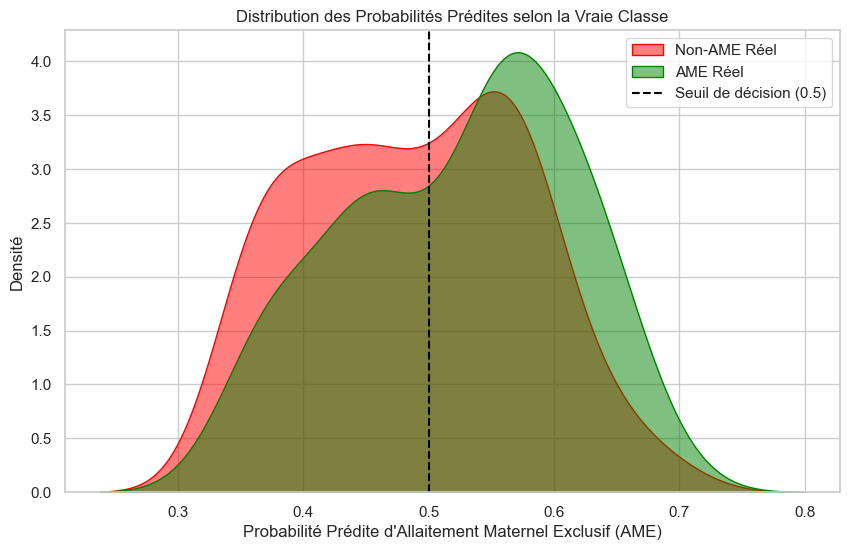

In [7]:
# 3. Distribution des Probabilités Prédites (KDE Plot)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
df_prob = pd.DataFrame({'Probabilité AME': y_prob_best, 'Vraie Classe': y_test})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_prob[df_prob['Vraie Classe'] == 0]['Probabilité AME'], label='Non-AME Réel', fill=True, color='red', alpha=0.5)
sns.kdeplot(data=df_prob[df_prob['Vraie Classe'] == 1]['Probabilité AME'], label='AME Réel', fill=True, color='green', alpha=0.5)
plt.axvline(0.5, color='black', linestyle='--', label='Seuil de décision (0.5)')
plt.title('Distribution des Probabilités Prédites selon la Vraie Classe')
plt.xlabel('Probabilité Prédite d\'Allaitement Maternel Exclusif (AME)')
plt.ylabel('Densité')
plt.legend()
plt.show()

## 4. Stress Test et Sauvegarde

In [8]:
np.random.seed(99)
X_stress = X_test.sample(n=1000, replace=True, random_state=99).copy()
for col in X_stress.columns:
    mask = np.random.rand(1000) < 0.05
    X_stress.loc[mask, col] = 1 - X_stress.loc[mask, col]

y_pred_stress = best_model.predict(X_stress)
y_prob_stress = best_model.predict_proba(X_stress)[:, 1]

df_stress_results = pd.DataFrame({'Probabilité_AME': y_prob_stress.round(3), 'Prediction_Classe': y_pred_stress})
print(df_stress_results['Prediction_Classe'].value_counts(normalize=True)*100)

os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/modele_ml_allaitement.joblib')
with open('model/modele_ml_allaitement.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
# Sauvegarde des colonnes d'entrainement pour le modèle en production (Streamlit)
joblib.dump(X_train.columns.tolist(), 'model/model_columns.joblib')

print("Modèles et colonnes sauvegardés dans /model")

Prediction_Classe
0    54.1
1    45.9
Name: proportion, dtype: float64
Modèles et colonnes sauvegardés dans /model
